In [1]:
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv("Dummy Data HSS.csv")

In [3]:
df.shape

(4572, 5)

Dataset Overview

The dataset contains 4572 observations and 5 variables related to marketing activities and sales. It will be used to understand the impact of different marketing channels on sales using Marketing Mix Modeling.

In [4]:
df.head

<bound method NDFrame.head of         TV      Radio  Social Media Influencer       Sales
0     16.0   6.566231      2.907983       Mega   54.732757
1     13.0   9.237765      2.409567       Mega   46.677897
2     41.0  15.886446      2.913410       Mega  150.177829
3     83.0  30.020028      6.922304       Mega  298.246340
4     15.0   8.437408      1.405998      Micro   56.594181
...    ...        ...           ...        ...         ...
4567  26.0   4.472360      0.717090      Micro   94.685866
4568  71.0  20.610685      6.545573       Nano  249.101915
4569  44.0  19.800072      5.096192      Micro  163.631457
4570  71.0  17.534640      1.940873      Macro  253.610411
4571  42.0  15.966688      5.046548      Micro  148.202414

[4572 rows x 5 columns]>

Objective

The objective of this project is to identify the contribution of different marketing channels toward sales and recommend optimal marketing budget allocation.

In [5]:
df.columns

Index(['TV', 'Radio', 'Social Media', 'Influencer', 'Sales'], dtype='object')

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df.describe()

,TV,Radio,Social Media,Sales
count,4562.000000,4568.000000,4566.000000,4566.000000
mean,54.066857,18.160356,3.323956,192.466602
std,26.125054,9.676958,2.212670,93.133092
min,10.000000,0.000684,0.000031,31.199409
25%,32.000000,10.525957,1.527849,112.322882
50%,53.000000,17.859513,3.055565,189.231172
75%,77.000000,25.649730,4.807558,272.507922
max,100.000000,48.871161,13.981662,364.079751


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social Media  4566 non-null   float64
 3   Influencer    4572 non-null   object 
 4   Sales         4566 non-null   float64
dtypes: float64(4), object(1)
memory usage: 178.7+ KB


In [9]:
df.isnull().sum()

TV              10
Radio            4
Social Media     6
Influencer       0
Sales            6
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

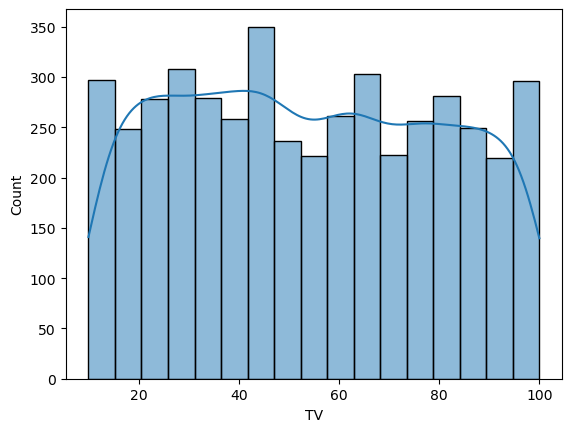

In [11]:
sns.histplot(df["TV"], kde=True)
plt.show()

In [12]:
df["TV"] = df["TV"].fillna(df["TV"].median())

I checked the distribution using a histogram. Since the TV spend was not normally distributed, I used the median because it is more robust to non-normal distributions and potential outliers.

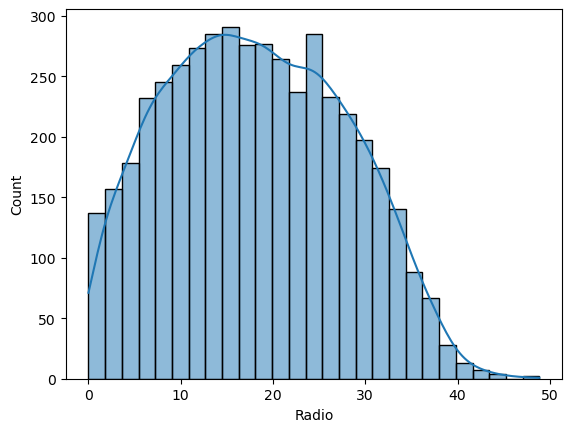

In [13]:
sns.histplot(df["Radio"], kde=True)
plt.show()

In [14]:
df["Radio"] = df["Radio"].fillna(df["Radio"].median())

The Radio column was positively skewed, so I used median imputation because the median is less affected by skewness and extreme values than the mean.

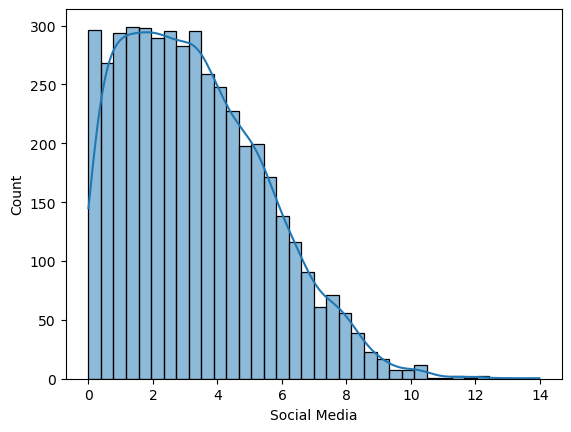

In [15]:
sns.histplot(df["Social Media"], kde=True)
plt.show()

In [16]:
df["Social Media"] = df["Social Media"].fillna(df["Social Media"].median())

The Social Media column is also positively skewed, so I used median imputation.

In [17]:
df = df.dropna(subset=["Sales"])

The Sales column is the target (dependent) variable in this Marketing Mix Modeling project. It contained **6 missing values** (approximately **0.13%** of the dataset).

Instead of imputing these values, I removed the corresponding rows using `dropna()` because imputing the target variable could introduce bias into the regression model. Since the percentage of missing values was very small, removing these rows had a negligible impact on the overall dataset.

In [18]:
df.isnull().sum()

TV              0
Radio           0
Social Media    0
Influencer      0
Sales           0
dtype: int64

In [19]:
df.dtypes

TV              float64
Radio           float64
Social Media    float64
Influencer       object
Sales           float64
dtype: object

In [20]:
df["Influencer"].unique()

array(['Mega', 'Micro', 'Nano', 'Macro'], dtype=object)

In [21]:
df["Influencer"].value_counts()

Influencer
Mega     1156
Micro    1152
Nano     1137
Macro    1121
Name: count, dtype: int64

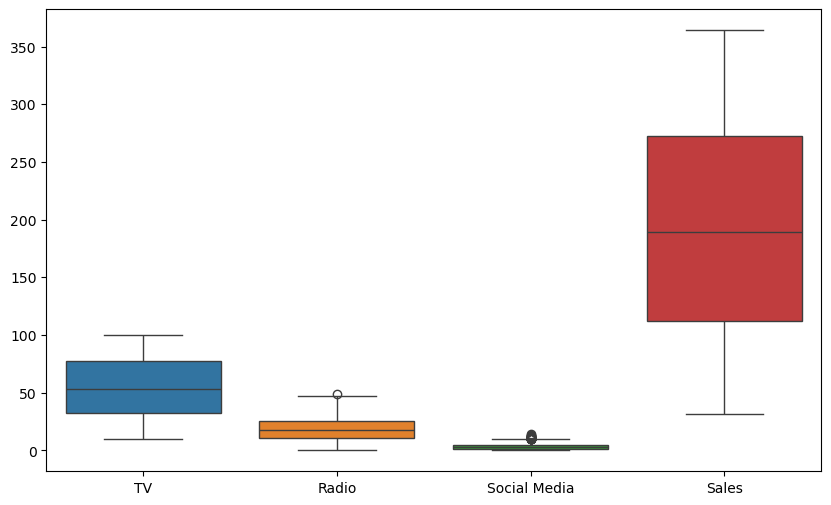

In [22]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df[['TV','Radio','Social Media','Sales']])
plt.show()

Outlier Analysis

Boxplots were created for all numerical variables (TV, Radio, Social Media, and Sales) to identify potential outliers.

A few outliers were observed in the Radio and Social Media columns. Since these values may represent genuine high-budget marketing campaigns rather than data entry errors, they were retained for further analysis. No significant outliers were observed in the TV and Sales columns.

The dataset is clean and ready for exploratory data analysis.

In [23]:
df.describe()

,TV,Radio,Social Media,Sales
count,4566.000000,4566.000000,4566.000000,4566.000000
mean,54.065703,18.161353,3.324830,192.466602
std,26.088376,9.668593,2.210751,93.133092
min,10.000000,0.000684,0.000031,31.199409
25%,32.000000,10.555355,1.532511,112.322882
50%,53.000000,17.859513,3.055565,189.231172
75%,77.000000,25.648333,4.804919,272.507922
max,100.000000,48.871161,13.981662,364.079751


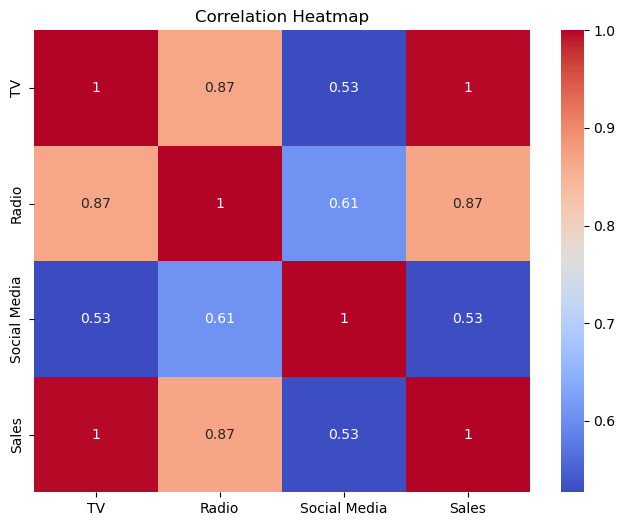

In [24]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

TV advertising appears to have the strongest relationship with Sales, followed by Radio. Social Media also contributes positively, but its relationship with Sales is comparatively weaker.

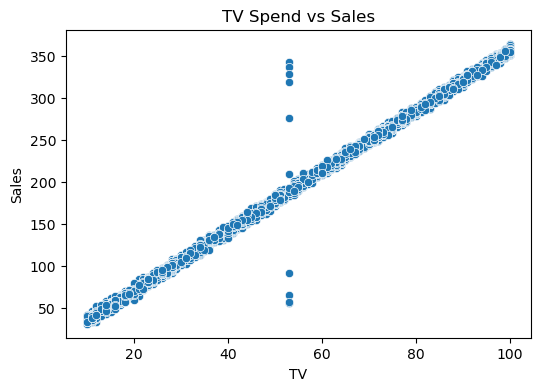

In [25]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="TV", y="Sales", data=df)
plt.title("TV Spend vs Sales")
plt.show()

Increasing TV advertising budget is associated with higher Sales in this dataset.

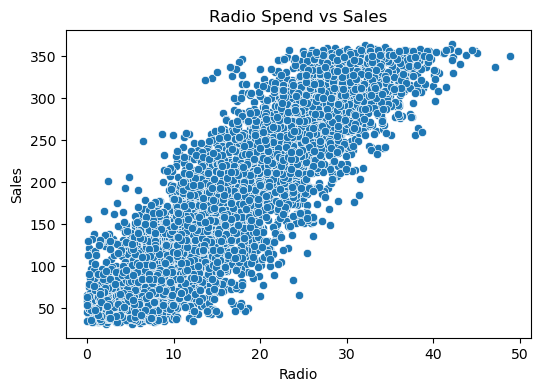

In [26]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="Radio", y="Sales", data=df)
plt.title("Radio Spend vs Sales")
plt.show()

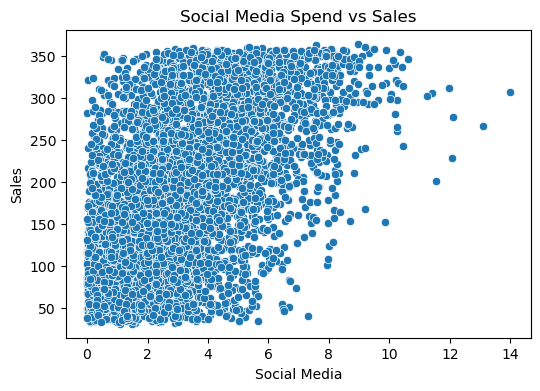

In [27]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="Social Media", y="Sales", data=df)
plt.title("Social Media Spend vs Sales")
plt.show()

Social Media contributes to Sales,
but other factors may also influence its effectiveness.

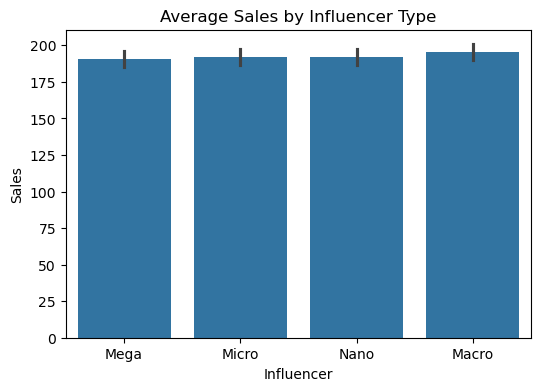

In [28]:
plt.figure(figsize=(6,4))
sns.barplot(x="Influencer", y="Sales", data=df)
plt.title("Average Sales by Influencer Type")
plt.show()

All influencer types generate similar average Sales in this dataset.
Macro appears to have a slightly higher average, but the differences are small.

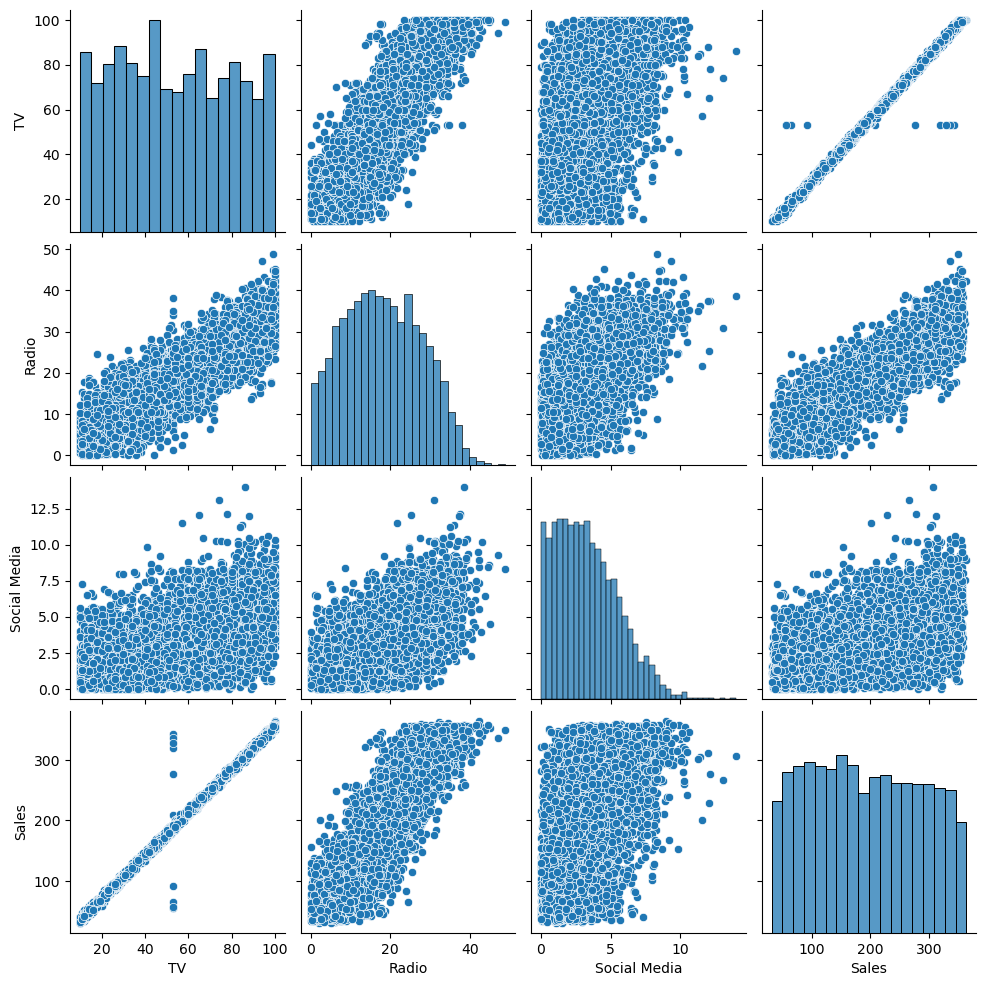

In [29]:
sns.pairplot(df)
plt.show()

# Feature Engineering

## Objective

The objective is to understand how marketing variables can be transformed into more meaningful features for Marketing Mix Modeling.

## Concepts Covered

- Feature Engineering
- Adstock (Carryover Effect)
- Saturation (Diminishing Returns)

## Observation

The current dataset does not contain a Date column, so a true Adstock transformation cannot be calculated. However, the concepts are essential for real-world MMM projects and were studied as part of this project.

In [31]:
# Independent Variables (Features)
X = df[['TV', 'Radio', 'Social Media']]

# Dependent Variable (Target)
y = df['Sales']

In [34]:
X.head()

,TV,Radio,Social Media
0,16.0,6.566231,2.907983
1,13.0,9.237765,2.409567
2,41.0,15.886446,2.913410
3,83.0,30.020028,6.922304
4,15.0,8.437408,1.405998


In [35]:
y.head()

0     54.732757
1     46.677897
2    150.177829
3    298.246340
4     56.594181
Name: Sales, dtype: float64

The dataset was divided into independent variables (X) and the dependent variable (y).

- **X (Features):** TV, Radio, Social Media
- **y (Target):** Sales

The Influencer column was excluded at this stage because it is categorical and requires encoding before it can be used in a regression model.

In [36]:
X.shape

(4566, 3)

In [37]:
y.shape

(4566,)

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [39]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(3652, 3)
(914, 3)
(3652,)
(914,)


## Step 2: Train-Test Split

The dataset was divided into training and testing sets using an 80:20 ratio.

- Training Data (80%) was used to train the Linear Regression model.
- Testing Data (20%) was used to evaluate the model's performance on unseen data.

A fixed `random_state=42` was used to ensure the split is reproducible.

In [40]:
from sklearn.linear_model import LinearRegression

# Create the model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Step 3: Building the Linear Regression Model

A Linear Regression model was created using Scikit-learn.

The model was trained using the training dataset (`X_train` and `y_train`) to learn the relationship between the marketing channels (TV, Radio, and Social Media) and Sales.

In [41]:
# Predict Sales for the test data
y_pred = model.predict(X_test)

In [42]:
y_pred[:10]

array([127.04246536, 182.65482488,  74.57305808, 306.92190022,
       125.15238498, 303.87521356, 327.91159651,  60.14132119,
       106.81108871, 209.91405309])

In [43]:
comparison = pd.DataFrame({
    'Actual Sales': y_test.values,
    'Predicted Sales': y_pred
})

comparison.head(10)

,Actual Sales,Predicted Sales
0,127.664697,127.042465
1,180.374609,182.654825
2,75.124159,74.573058
3,310.350396,306.921900
4,118.101651,125.152385
5,309.666256,303.875214
6,321.750467,327.911597
7,55.792759,60.141321
8,105.540287,106.811089
9,211.230183,209.914053


## Step 4: Making Predictions

The trained Linear Regression model was used to predict Sales for the unseen testing dataset (`X_test`).

The predicted values (`y_pred`) were then compared with the actual Sales (`y_test`) to evaluate the model's performance.

### Observation

The predicted Sales values are very close to the actual Sales values, indicating that the Linear Regression model has successfully captured the relationship between the marketing channels and Sales. Small differences are expected because predictions are estimates rather than exact values.

In [44]:
print("Intercept:", model.intercept_)

print("Coefficients:", model.coef_)

Intercept: -0.28321325375014794
Coefficients: [3.51504629 0.13553205 0.06345643]


## Regression Equation

The Linear Regression model learned the following equation:

Sales = -0.283 + 3.515(TV) + 0.136(Radio) + 0.063(Social Media)

The coefficients indicate the expected change in Sales for a one-unit increase in each marketing channel, assuming the other variables remain constant.

Among all the channels, TV has the highest coefficient, suggesting it has the strongest influence on Sales in this dataset.

In [45]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.9960008386886494


In [46]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 2.5661920411834354


In [47]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)

MSE: 34.48720596905167


In [48]:
import numpy as np

rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 5.872580861005805


## Model Evaluation

The Linear Regression model was evaluated using four performance metrics:

- **R² Score** measures how well the independent variables explain the variation in Sales.
- **MAE** measures the average absolute prediction error.
- **MSE** gives a larger penalty to bigger prediction errors.
- **RMSE** represents the average prediction error in the same unit as Sales.

A good model should have:
- High R² Score
- Low MAE
- Low MSE
- Low RMSE

## Model Performance

The Linear Regression model performed exceptionally well.

- **R² Score = 99.6%**, indicating that the model explains almost all the variation in Sales.
- **MAE = 2.57**, meaning the average prediction error is approximately 2.57 units.
- **RMSE = 5.87**, indicating that the model's predictions are generally within about 6 units of the actual Sales values.

Overall, the model demonstrates excellent predictive performance on the testing dataset.

In [49]:
roi_df = df.copy()

In [50]:
roi_df['Marketing Cost'] = (
    roi_df['TV']
    + roi_df['Radio']
    + roi_df['Social Media']
)

In [51]:
roi_df['Profit'] = (
    roi_df['Sales']
    - roi_df['Marketing Cost']
)

In [52]:
roi_df['ROI (%)'] = (
    roi_df['Profit']
    / roi_df['Marketing Cost']
) * 100

In [53]:
roi_df.head()

,TV,Radio,Social Media,Influencer,Sales,Marketing Cost,Profit,ROI (%)
0,16.0,6.566231,2.907983,Mega,54.732757,25.474214,29.258544,114.855532
1,13.0,9.237765,2.409567,Mega,46.677897,24.647332,22.030565,89.383165
2,41.0,15.886446,2.913410,Mega,150.177829,59.799856,90.377973,151.134097
3,83.0,30.020028,6.922304,Mega,298.246340,119.942332,178.304008,148.658113
4,15.0,8.437408,1.405998,Micro,56.594181,24.843406,31.750775,127.803632


In [54]:
roi_df['ROI (%)'].mean()

np.float64(154.72503720845236)

# ROI Analysis

The dataset did not contain actual marketing cost or revenue information. Therefore, an estimated ROI was calculated using the following assumptions:

- Sales was considered as Revenue.
- Total Marketing Cost was calculated as the sum of TV, Radio, and Social Media spends.
- Profit = Sales − Marketing Cost.
- ROI (%) = (Profit / Marketing Cost) × 100.

This estimated ROI helps compare the efficiency of marketing investments for learning and demonstration purposes.

# Business Recommendations

Based on the Marketing Mix Modeling analysis, the following recommendations are proposed:

- TV advertising has the strongest positive impact on Sales and should receive the highest marketing budget.
- Radio advertising contributes positively and should continue to be part of the marketing strategy with ongoing performance monitoring.
- Social Media has the lowest contribution in the current model. Campaign optimization should be considered before increasing investment.
- The estimated average ROI is approximately **154.73%**, indicating that the marketing campaigns are profitable under the assumptions used in this project.
- The Linear Regression model achieved an R² Score of **99.6%**, demonstrating excellent predictive performance.

In [55]:
roi_df.to_csv("MMM_Final_Dataset.csv", index=False)

In [56]:
roi_df.to_csv(r"C:\Users\Windows 11 Pro\Downloads\MMM_Final_Dataset.csv", index=False)